In [8]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [9]:
df = pd.read_excel("property_maintenance_project_dataset_corrected.xlsx")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [10]:

print(df.head())


print(df.tail())

   ticket_id  fine_amount  admin_fee  state_fee  late_fee  discount_amount  \
0      22000          100         20         10        25                0   
1      22001          750         20         10       100                0   
2      22002          500         20         10       100                0   
3      22003           50         20         10        75                0   
4      22004          100         20         10       100                0   

   clean_up_cost  judgment_amount  compliance  hearing_issued_date_diff  
0              0              854           0                      -253  
1              0              334           0                      -266  
2              0              496           0                       205  
3              0              658           1                       354  
4              0              521           0                       299  
       ticket_id  fine_amount  admin_fee  state_fee  late_fee  \
14995      36995      

In [11]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset:
(15000, 10)

Column Names:
Index(['ticket_id', 'fine_amount', 'admin_fee', 'state_fee', 'late_fee',
       'discount_amount', 'clean_up_cost', 'judgment_amount', 'compliance',
       'hearing_issued_date_diff'],
      dtype='object')

Data Types:
ticket_id                   int64
fine_amount                 int64
admin_fee                   int64
state_fee                   int64
late_fee                    int64
discount_amount             int64
clean_up_cost               int64
judgment_amount             int64
compliance                  int64
hearing_issued_date_diff    int64
dtype: object


In [12]:
print(df.isnull().sum())

ticket_id                   0
fine_amount                 0
admin_fee                   0
state_fee                   0
late_fee                    0
discount_amount             0
clean_up_cost               0
judgment_amount             0
compliance                  0
hearing_issued_date_diff    0
dtype: int64


In [13]:
print(df.describe())

          ticket_id   fine_amount  admin_fee  state_fee      late_fee  \
count  15000.000000  15000.000000    15000.0    15000.0  15000.000000   
mean   29499.500000    401.980000       20.0       10.0     35.674667   
std     4330.271354    328.647146        0.0        0.0     33.642983   
min    22000.000000     50.000000       20.0       10.0      0.000000   
25%    25749.750000    100.000000       20.0       10.0     10.000000   
50%    29499.500000    250.000000       20.0       10.0     25.000000   
75%    33249.250000    750.000000       20.0       10.0     50.000000   
max    36999.000000   1000.000000       20.0       10.0    100.000000   

       discount_amount  clean_up_cost  judgment_amount    compliance  \
count     15000.000000   15000.000000     15000.000000  15000.000000   
mean          6.293333      11.063333       639.744000      0.284667   
std          13.511950      30.229625       322.141882      0.451271   
min           0.000000       0.000000        80.000000

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


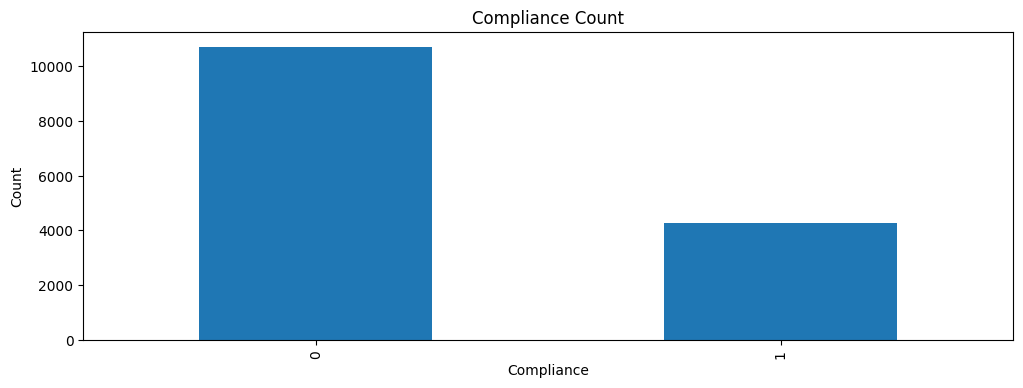

In [20]:
%matplotlib inline
df['compliance'].value_counts().plot(kind='bar')

plt.title("Compliance Count")
plt.xlabel("Compliance")
plt.ylabel("Count")

plt.show()

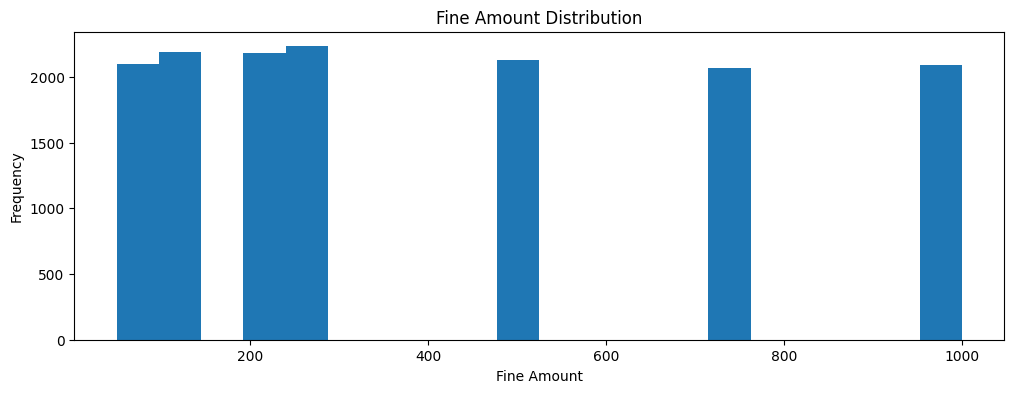

In [21]:
plt.hist(df['fine_amount'], bins=20)

plt.title("Fine Amount Distribution")
plt.xlabel("Fine Amount")
plt.ylabel("Frequency")

plt.show()

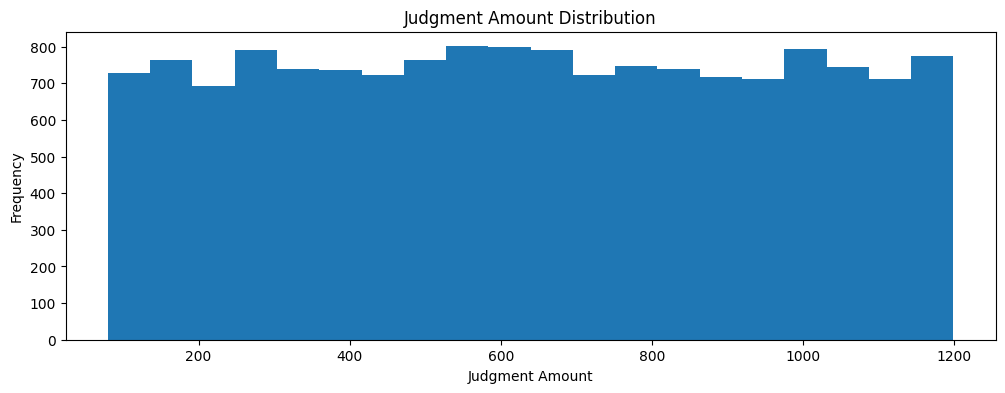

In [22]:
plt.hist(df['judgment_amount'], bins=20)

plt.title("Judgment Amount Distribution")
plt.xlabel("Judgment Amount")
plt.ylabel("Frequency")

plt.show()

In [23]:
X = df.drop("compliance", axis=1)

y = df["compliance"]

print(X.head())
print(y.head())

   ticket_id  fine_amount  admin_fee  state_fee  late_fee  discount_amount  \
0      22000          100         20         10        25                0   
1      22001          750         20         10       100                0   
2      22002          500         20         10       100                0   
3      22003           50         20         10        75                0   
4      22004          100         20         10       100                0   

   clean_up_cost  judgment_amount  hearing_issued_date_diff  
0              0              854                      -253  
1              0              334                      -266  
2              0              496                       205  
3              0              658                       354  
4              0              521                       299  
0    0
1    0
2    0
3    1
4    0
Name: compliance, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (12000, 9)
Testing Data Shape: (3000, 9)


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Model Training Completed


In [27]:
y_pred = model.predict(X_test_scaled)

print(y_pred)

[0 0 0 ... 0 0 0]


In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(accuracy)

Accuracy Score:
0.711


In [29]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2133    0]
 [ 867    0]]


In [30]:
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      2133
           1       0.00      0.00      0.00       867

    accuracy                           0.71      3000
   macro avg       0.36      0.50      0.42      3000
weighted avg       0.51      0.71      0.59      3000



In [31]:
sample = X_test.iloc[0:1]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Prediction Result:")
print(prediction)

if prediction[0] == 1:
    print("Person is likely to comply with fine")
else:
    print("Person is NOT likely to comply with fine")

Prediction Result:
[0]
Person is NOT likely to comply with fine


In [32]:
import joblib

joblib.dump(model, "fine_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [34]:
loaded_model = joblib.load("fine_prediction_model.pkl")

print("Saved Model Loaded Successfully")


Saved Model Loaded Successfully
